# Activity Analysis

This notebook focuses on understanding the available activity labels and sensor signals before choosing any final prediction method.

## 1. Setup

In [11]:
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from scipy.signal import welch

from mhealth_activity import Recording
from mhealth_activity.activity_recognition import activity_f1_summary, build_activity_recognizer, evaluate_activity_recognizer

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 200)

TRAIN_DIR = Path(r"c:\Users\giaco\Desktop\ETH\Mobile_Health\DATA\data\train")
TEST_DIR = Path(r"c:\Users\giaco\Desktop\ETH\Mobile_Health\DATA\data\test")

ACTIVITY_ORDER = ["standing", "walking", "running", "cycling"]
ACTIVITY_TO_ID = {name: idx for idx, name in enumerate(ACTIVITY_ORDER)}
ID_TO_ACTIVITY = {idx: name for name, idx in ACTIVITY_TO_ID.items()}

TRAIN_DIR, TRAIN_DIR.exists(), TEST_DIR.exists()

(WindowsPath('c:/Users/giaco/Desktop/ETH/Mobile_Health/DATA/data/train'),
 True,
 True)

## 2. Label Normalization And Shared Helpers

The activity labels are stored in mixed formats, so the first step is to normalize them into a consistent list of activity names.

In [12]:
def normalize_activities(raw_value):
    if isinstance(raw_value, dict):
        labels = [name for name in ACTIVITY_ORDER if bool(raw_value.get(name, False))]
    elif isinstance(raw_value, (list, tuple, set, np.ndarray)):
        parsed = []
        for item in raw_value:
            if isinstance(item, (int, np.integer)) and int(item) in ID_TO_ACTIVITY:
                parsed.append(ID_TO_ACTIVITY[int(item)])
            elif isinstance(item, str):
                label = item.strip().lower()
                if label in ACTIVITY_TO_ID:
                    parsed.append(label)
        labels = [name for name in ACTIVITY_ORDER if name in set(parsed)]
    else:
        labels = []

    return labels


def parse_trace_id(path):
    return int(path.stem.split("_")[-1])


SENSOR_GROUPS = {
    "watch_acc": ["ax", "ay", "az"],
    "watch_gyr": ["gx", "gy", "gz"],
    "watch_mag": ["mx", "my", "mz"],
    "phone_acc": ["phone_ax", "phone_ay", "phone_az"],
    "phone_gyr": ["phone_gx", "phone_gy", "phone_gz"],
    "phone_linacc": ["phone_lax", "phone_lay", "phone_laz"],
}


MOTION_GROUPS = {
    "watch_acc": ["ax", "ay", "az"],
    "watch_gyr": ["gx", "gy", "gz"],
    "phone_acc": ["phone_ax", "phone_ay", "phone_az"],
    "phone_gyr": ["phone_gx", "phone_gy", "phone_gz"],
    "phone_linacc": ["phone_lax", "phone_lay", "phone_laz"],
}


## 3. Build Metadata Tables

This block converts all training traces into a compact metadata table that we will use for the rest of the analysis.

In [13]:
rows = []
sensor_counter = Counter()
samplerate_rows = []

for path in sorted(TRAIN_DIR.glob("*.pkl")):
    rec = Recording(str(path))
    labels = rec.labels or {}
    activities = normalize_activities(labels.get("activities", []))

    row = {
        "file": path.name,
        "trace_id": parse_trace_id(path),
        "path_idx": labels.get("path_idx"),
        "watch_loc": labels.get("watch_loc"),
        "n_sensors": len(rec.data),
        "duration_s": rec.data["ax"].total_time if "ax" in rec.data else np.nan,
        "activity_combo": " + ".join(activities) if activities else "none",
        "n_activities": len(activities),
    }

    for activity in ACTIVITY_ORDER:
        row[activity] = activity in activities

    rows.append(row)

    for sensor_name, trace in rec.data.items():
        sensor_counter[sensor_name] += 1
        samplerate_rows.append(
            {
                "file": path.name,
                "sensor": sensor_name,
                "samplerate_hz": trace.samplerate,
                "duration_s": trace.total_time,
            }
        )

metadata_df = pd.DataFrame(rows).sort_values("trace_id").reset_index(drop=True)

samplerate_df = pd.DataFrame(samplerate_rows)
sensor_summary_df = (
    pd.Series(sensor_counter, name="count")
    .sort_values(ascending=False)
    .rename_axis("sensor")
    .reset_index()
)

metadata_df.head()

,file,trace_id,path_idx,watch_loc,n_sensors,duration_s,activity_combo,n_activities,standing,walking,running,cycling
0,train_trace_000.pkl,0,0,0,37,576.042,walking,1,False,True,False,False
1,train_trace_001.pkl,1,1,1,42,788.925,standing + walking,2,True,True,False,False
2,train_trace_002.pkl,2,0,2,41,540.746,walking,1,False,True,False,False
3,train_trace_003.pkl,3,2,0,42,733.139,walking,1,False,True,False,False
4,train_trace_004.pkl,4,4,1,42,530.442,walking,1,False,True,False,False


## 4. Global Label Overview

These cells summarize the full training set before we isolate cleaner subsets.

In [23]:
print(f"Training recordings: {len(metadata_df)}")
print(f"Unique activity combinations: {metadata_df['activity_combo'].nunique()}")
print()
print("Number of active labels per recording")
display(metadata_df["n_activities"].value_counts().sort_index().rename("count"))
print()
print("Most frequent activity combinations")
display(metadata_df["activity_combo"].value_counts().head(15).rename("count"))
print()
print("Per-activity counts")
display(metadata_df[ACTIVITY_ORDER].sum().rename("count"))


Training recordings: 396
Unique activity combinations: 10

Number of active labels per recording


n_activities
1    246
2    106
3     41
4      3
Name: count, dtype: int64


Most frequent activity combinations


activity_combo
walking                                   218
standing + walking                         51
walking + running                          33
standing + walking + running               29
walking + cycling                          20
cycling                                    19
standing + walking + cycling               12
running                                     9
standing + walking + running + cycling      3
running + cycling                           2
Name: count, dtype: int64


Per-activity counts


standing     95
walking     366
running      76
cycling      56
Name: count, dtype: int64

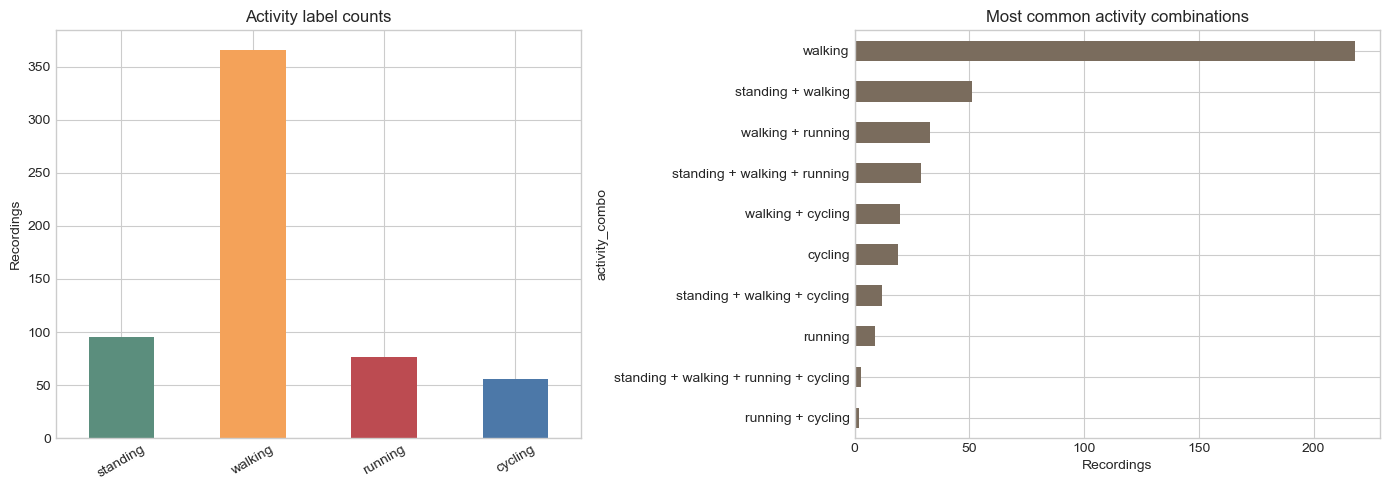

: 

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

activity_counts = metadata_df[ACTIVITY_ORDER].sum().reindex(ACTIVITY_ORDER)
activity_counts.plot(kind="bar", ax=axes[0], color=["#5B8E7D", "#F4A259", "#BC4B51", "#4C78A8"])
axes[0].set_title("Activity label counts")
axes[0].set_ylabel("Recordings")
axes[0].tick_params(axis="x", rotation=30)

combo_counts = metadata_df["activity_combo"].value_counts().head(12).sort_values()
combo_counts.plot(kind="barh", ax=axes[1], color="#7A6C5D")
axes[1].set_title("Most common activity combinations")
axes[1].set_xlabel("Recordings")

plt.tight_layout()
plt.show()

C:\Users\giaco\AppData\Local\Temp\ipykernel_2456\996353923.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(duration_by_activity, labels=ACTIVITY_ORDER)


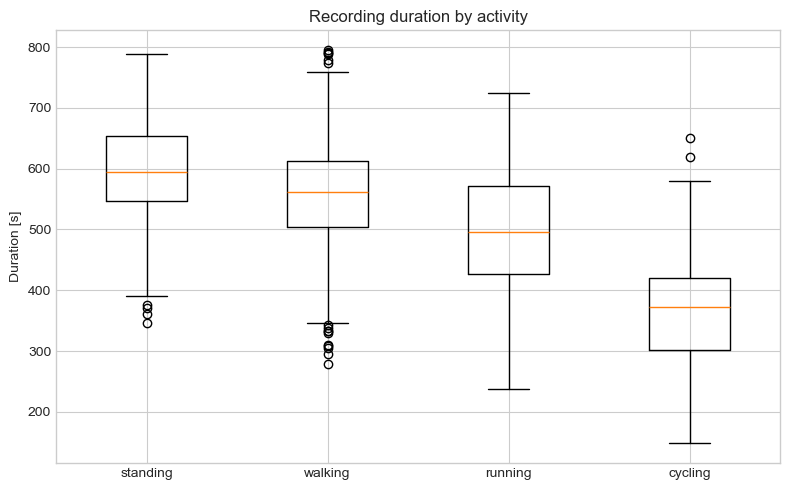

,duration_s
activity_combo,
standing + walking,637.5570
standing + walking + running + cycling,579.3260
standing + walking + running,576.6280
walking,567.6265
walking + running,466.6000
standing + walking + cycling,463.6340
walking + cycling,385.3290
running + cycling,376.3505
running,278.2060


: 

In [ ]:
duration_by_activity = []
for activity in ACTIVITY_ORDER:
    subset = metadata_df.loc[metadata_df[activity], "duration_s"].dropna()
    duration_by_activity.append(subset.values)

fig, ax = plt.subplots(figsize=(8, 5))
ax.boxplot(duration_by_activity, labels=ACTIVITY_ORDER)
ax.set_title("Recording duration by activity")
ax.set_ylabel("Duration [s]")
plt.tight_layout()
plt.show()

metadata_df.groupby("activity_combo")[["duration_s"]].median().sort_values("duration_s", ascending=False).head(12)

## 5. Sensor Coverage And Samplerates

Before comparing activities, it helps to confirm which sensors are consistently available and at what approximate rates.

In [22]:
sensor_summary_df.head(20)

,sensor,count
0,phone_mx,396
1,phone_lax,396
2,phone_mz,396
3,phone_rotm,396
4,gx,396
5,packetNumber,396
6,phone_gravz,396
7,phone_gx,396
8,phone_laz,396
9,az,396


In [ ]:
samplerate_summary = (
    samplerate_df.groupby("sensor")["samplerate_hz"]
    .agg(["median", "mean", "min", "max"])
    .sort_values("median", ascending=False)
)
samplerate_summary.head(20)

,median,mean,min,max
sensor,,,,
ay,200.021206,199.910985,192.212459,200.439764
az,200.021206,199.910985,192.212459,200.439764
gx,200.021206,199.910985,192.212459,200.439764
gy,200.021206,199.910985,192.212459,200.439764
gz,200.021206,199.910985,192.212459,200.439764
ax,200.021206,199.910985,192.212459,200.439764
phone_magrotz,198.204511,197.709510,50.029811,503.695574
phone_magroty,198.204511,197.709538,50.029811,503.695574
phone_magrotx,198.204511,197.709513,50.029811,503.695574


: 

## 6. Single-Label Prototype Subset

This is the cleanest subset for understanding how each activity looks in isolation. Each recording here contributes to exactly one activity only.

In [21]:
single_label_df = metadata_df.loc[metadata_df["n_activities"] == 1].copy()
single_label_df["activity_label"] = single_label_df[ACTIVITY_ORDER].idxmax(axis=1)

multi_label_df = metadata_df.loc[metadata_df["n_activities"] > 1].copy()

print(f"Single-label recordings: {len(single_label_df)}")
print(f"Multi-label recordings: {len(multi_label_df)}")
print()
display(single_label_df["activity_label"].value_counts().reindex(ACTIVITY_ORDER).rename("count"))
print()
single_label_df[["file", "activity_label", "path_idx", "watch_loc", "duration_s"]].head(10)

Single-label recordings: 246
Multi-label recordings: 150



activity_label
standing      NaN
walking     218.0
running       9.0
cycling      19.0
Name: count, dtype: float64

,file,activity_label,path_idx,watch_loc,duration_s
0,train_trace_000.pkl,walking,0,0,576.042
2,train_trace_002.pkl,walking,0,2,540.746
3,train_trace_003.pkl,walking,2,0,733.139
4,train_trace_004.pkl,walking,4,1,530.442
5,train_trace_005.pkl,walking,2,2,505.522
6,train_trace_006.pkl,cycling,4,0,165.465
7,train_trace_007.pkl,walking,4,0,560.976
13,train_trace_013.pkl,walking,2,1,615.610
15,train_trace_015.pkl,running,1,2,286.559
17,train_trace_017.pkl,cycling,0,0,320.087


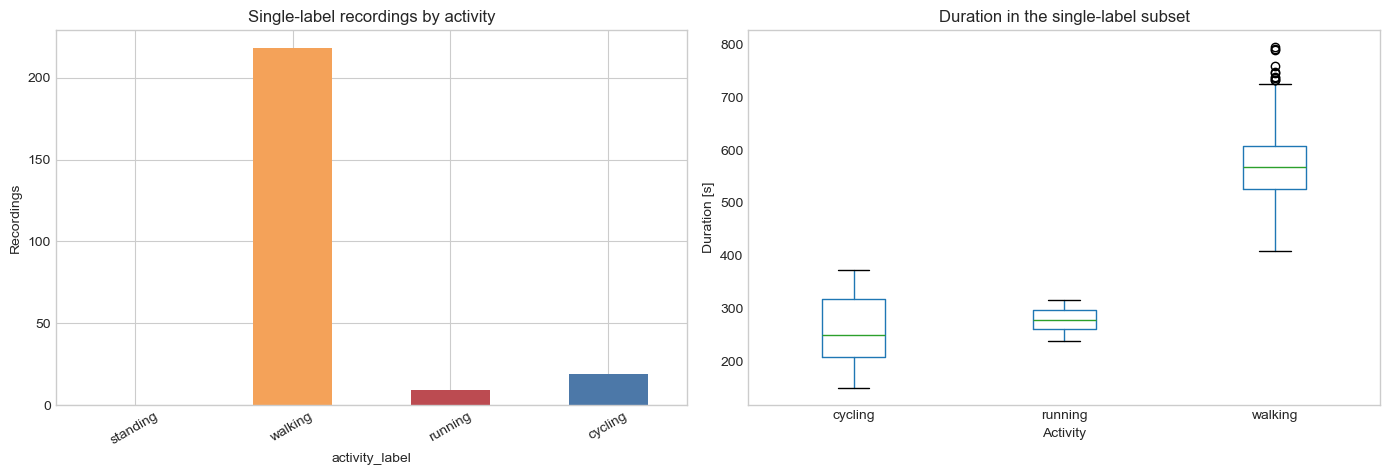

: 

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

single_counts = single_label_df["activity_label"].value_counts().reindex(ACTIVITY_ORDER)
single_counts.plot(kind="bar", ax=axes[0], color=["#5B8E7D", "#F4A259", "#BC4B51", "#4C78A8"])
axes[0].set_title("Single-label recordings by activity")
axes[0].set_ylabel("Recordings")
axes[0].tick_params(axis="x", rotation=30)

single_label_df.boxplot(column="duration_s", by="activity_label", ax=axes[1], grid=False)
axes[1].set_title("Duration in the single-label subset")
axes[1].set_xlabel("Activity")
axes[1].set_ylabel("Duration [s]")

plt.suptitle("")
plt.tight_layout()
plt.show()

## 7. Hand-Crafted Feature Comparison For Clean Prototypes

The goal here is not to train a model yet. We only compute a few interpretable motion-based summary features to see whether the single-label recordings separate naturally.

In [31]:
def get_axis_stack(recording, keys):
    if not all(key in recording.data for key in keys):
        return None, None

    traces = [recording.data[key] for key in keys]
    usable_len = min(len(trace.values) for trace in traces)
    if usable_len < 32:
        return None, None

    stacked = np.vstack([trace.values[:usable_len].astype(float) for trace in traces])
    samplerate = float(np.mean([trace.samplerate for trace in traces]))
    return stacked, samplerate


def summarize_signal(values, samplerate):
    values = np.asarray(values, dtype=float)
    if len(values) == 0:
        return {
            "mean": np.nan,
            "std": np.nan,
            "rms": np.nan,
            "iqr": np.nan,
            "dom_freq": np.nan,
        }

    centered = values - np.mean(values)
    summary = {
        "mean": float(np.mean(values)),
        "std": float(np.std(values)),
        "rms": float(np.sqrt(np.mean(values ** 2))),
        "iqr": float(np.quantile(values, 0.75) - np.quantile(values, 0.25)),
    }

    if samplerate > 0 and len(values) >= 64:
        freqs, power = welch(centered, fs=samplerate, nperseg=min(256, len(values)))
        if len(power) > 1:
            summary["dom_freq"] = float(freqs[np.argmax(power[1:]) + 1])
        else:
            summary["dom_freq"] = 0.0
    else:
        summary["dom_freq"] = np.nan

    return summary


def extract_activity_features(recording):
    features = {}

    for prefix, keys in MOTION_GROUPS.items():
        stacked, samplerate = get_axis_stack(recording, keys)
        if stacked is None:
            continue

        magnitude = np.sqrt((stacked ** 2).sum(axis=0))
        for feature_name, value in summarize_signal(magnitude, samplerate).items():
            features[f"{prefix}_{feature_name}"] = value

    return features


In [ ]:
feature_rows = []

for row in single_label_df.itertuples(index=False):
    rec = Recording(str(TRAIN_DIR / row.file))
    features = extract_activity_features(rec)
    features["file"] = row.file
    features["activity_label"] = row.activity_label
    features["duration_s"] = row.duration_s
    features["path_idx"] = row.path_idx
    features["watch_loc"] = row.watch_loc
    feature_rows.append(features)

activity_feature_df = pd.DataFrame(feature_rows)
activity_feature_df.head()

,watch_acc_mean,watch_acc_std,watch_acc_rms,watch_acc_iqr,watch_acc_dom_freq,watch_gyr_mean,watch_gyr_std,watch_gyr_rms,watch_gyr_iqr,watch_gyr_dom_freq,phone_acc_mean,phone_acc_std,phone_acc_rms,phone_acc_iqr,phone_acc_dom_freq,phone_gyr_mean,phone_gyr_std,phone_gyr_rms,phone_gyr_iqr,phone_gyr_dom_freq,phone_linacc_mean,phone_linacc_std,phone_linacc_rms,phone_linacc_iqr,phone_linacc_dom_freq,file,activity_label,duration_s,path_idx,watch_loc
0,1.090610,0.272950,1.124247,0.421730,1.562603,129.937396,66.592341,146.007762,102.168110,1.562603,9.994750,3.325423,10.533445,5.585192,1.541785,0.720934,0.411257,0.829987,0.490076,1.541780,3.546456,1.691868,3.929347,1.952582,3.468375,train_trace_000.pkl,walking,576.042,0,0
1,1.527757,0.680396,1.672417,1.090976,2.345371,188.604295,123.887597,225.653976,223.447734,0.781790,9.978793,3.134416,10.459487,5.281580,1.953284,0.789438,0.408045,0.888658,0.493450,1.953515,3.414348,1.577800,3.761280,1.985661,4.297701,train_trace_002.pkl,walking,540.746,0,2
2,1.095046,0.270915,1.128061,0.329638,1.563312,64.124305,55.938331,85.094203,50.212159,1.563312,10.095213,2.639569,10.434589,3.100584,1.575183,0.872976,0.522957,1.017630,0.664201,1.575183,3.086058,1.961881,3.656875,2.224090,1.575183,train_trace_003.pkl,walking,733.139,2,0
3,1.029582,0.382393,1.098301,0.605252,2.344625,45.560119,23.655373,51.335184,29.435498,3.907708,10.265482,2.711951,10.617665,4.317904,1.940488,1.410683,0.849323,1.646625,1.026730,1.940488,3.886993,1.846041,4.303090,2.489766,1.940488,train_trace_004.pkl,walking,530.442,4,1
4,1.475380,0.683830,1.626152,1.026231,2.346708,165.321158,116.576260,202.289668,191.007230,0.782236,10.121124,3.964565,10.869909,6.530733,1.951958,1.264708,0.741361,1.465982,0.820050,0.780783,4.361671,1.924478,4.767367,2.311221,3.903916,train_trace_005.pkl,walking,505.522,2,2


: 

: 

In [ ]:
selected_features = [
    "watch_acc_std",
    "watch_acc_dom_freq",
    "watch_gyr_std",
    "phone_acc_std",
    "phone_gyr_std",
]

activity_feature_df.groupby("activity_label")[selected_features].median().reindex(ACTIVITY_ORDER).round(3)

,watch_acc_std,watch_acc_dom_freq,watch_gyr_std,phone_acc_std,phone_gyr_std
activity_label,,,,,
standing,NaN,NaN,NaN,NaN,NaN
walking,0.420,1.563,73.699,3.422,0.589
running,0.705,3.124,98.818,10.470,1.529
cycling,0.304,1.562,48.107,3.270,0.910


: 

: 

C:\Users\giaco\AppData\Local\Temp\ipykernel_20140\559667880.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(groups, labels=ACTIVITY_ORDER)
C:\Users\giaco\AppData\Local\Temp\ipykernel_20140\559667880.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(groups, labels=ACTIVITY_ORDER)
C:\Users\giaco\AppData\Local\Temp\ipykernel_20140\559667880.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(groups, labels=ACTIVITY_ORDER)
C:\Users\giaco\AppData\Local\Temp\ipykernel_20140\559667880.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' 

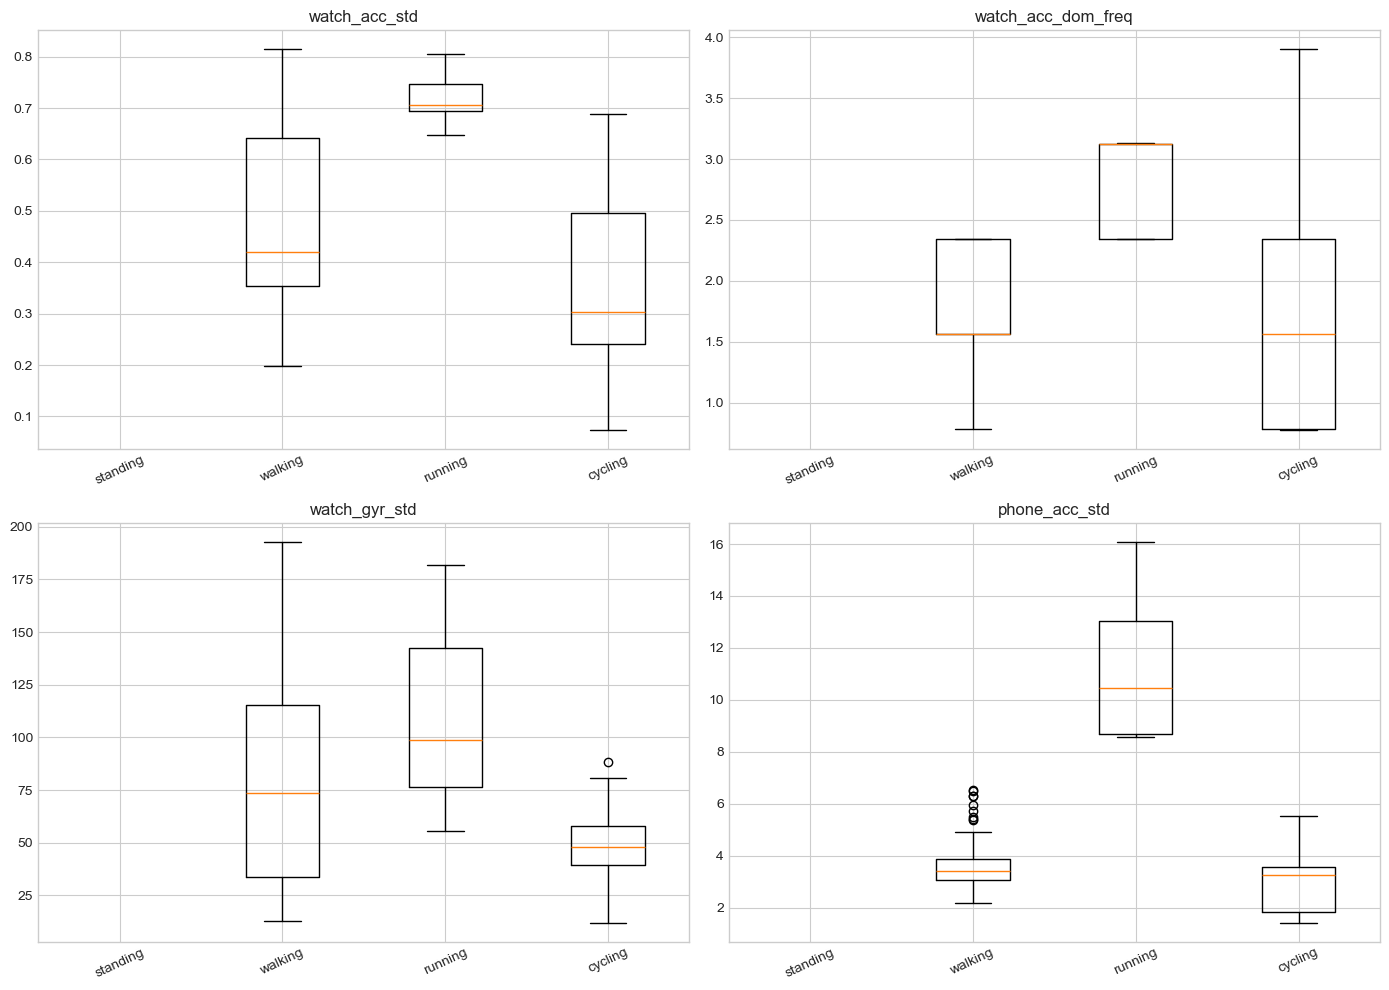

: 

: 

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
plot_features = ["watch_acc_std", "watch_acc_dom_freq", "watch_gyr_std", "phone_acc_std"]

for ax, feature_name in zip(axes.flat, plot_features):
    groups = [
        activity_feature_df.loc[activity_feature_df["activity_label"] == activity, feature_name].dropna().values
        for activity in ACTIVITY_ORDER
    ]
    ax.boxplot(groups, labels=ACTIVITY_ORDER)
    ax.set_title(feature_name)
    ax.tick_params(axis="x", rotation=25)

plt.tight_layout()
plt.show()

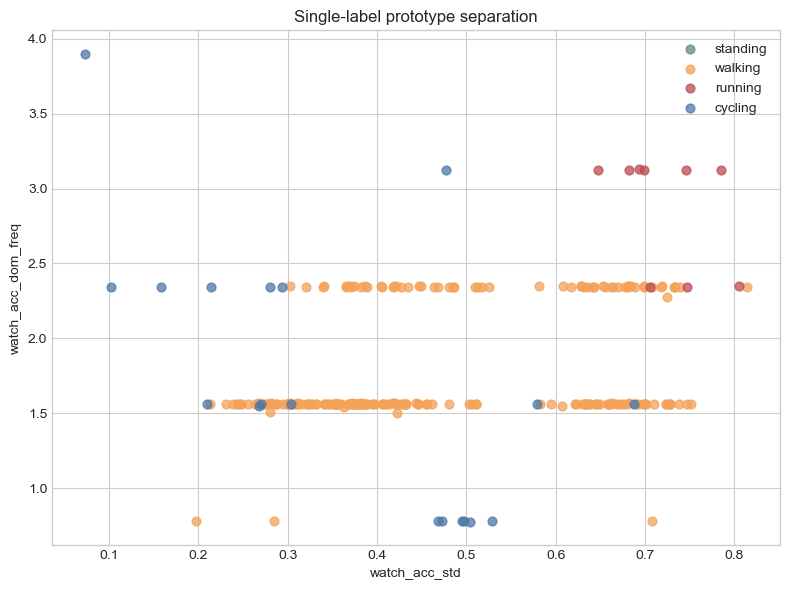

: 

: 

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))
colors = {
    "standing": "#5B8E7D",
    "walking": "#F4A259",
    "running": "#BC4B51",
    "cycling": "#4C78A8",
}

for activity in ACTIVITY_ORDER:
    subset = activity_feature_df.loc[activity_feature_df["activity_label"] == activity]
    ax.scatter(
        subset["watch_acc_std"],
        subset["watch_acc_dom_freq"],
        label=activity,
        alpha=0.75,
        s=40,
        color=colors[activity],
    )

ax.set_title("Single-label prototype separation")
ax.set_xlabel("watch_acc_std")
ax.set_ylabel("watch_acc_dom_freq")
ax.legend()
plt.tight_layout()
plt.show()

## 8. Watch-Location-Conditioned Analysis

The same activity can look different depending on whether the watch is on the wrist, belt, or ankle. These cells check whether the activity patterns become cleaner once we separate the single-label subset by watch location.

In [32]:
WATCH_LOC_NAMES = {0: "wrist", 1: "belt", 2: "ankle"}

single_label_df["watch_loc_name"] = single_label_df["watch_loc"].map(WATCH_LOC_NAMES).fillna(single_label_df["watch_loc"].astype(str))
activity_feature_df["watch_loc_name"] = activity_feature_df["watch_loc"].map(WATCH_LOC_NAMES).fillna(activity_feature_df["watch_loc"].astype(str))

watchloc_counts = pd.crosstab(single_label_df["activity_label"], single_label_df["watch_loc_name"])
watchloc_counts.reindex(index=ACTIVITY_ORDER, columns=["wrist", "belt", "ankle"]).fillna(0).astype(int)

NameError: name 'activity_feature_df' is not defined

In [ ]:
group_features = ["watch_acc_std", "watch_acc_dom_freq", "watch_gyr_std", "phone_acc_std"]

activity_feature_df.groupby(["watch_loc_name", "activity_label"])[group_features].median().round(3)

watch_acc_std  watch_acc_dom_freq  \
watch_loc_name activity_label                                      
ankle          cycling                 0.500               0.782   
               running                 0.784               2.348   
               walking                 0.671               1.563   
belt           cycling                 0.210               2.342   
               running                 0.720               3.127   
               walking                 0.396               1.563   
wrist          cycling                 0.275               1.953   
               running                 0.691               3.124   
               walking                 0.348               1.563   

                               watch_gyr_std  phone_acc_std  
watch_loc_name activity_label                                
ankle          cycling                60.435          3.320  
               running               173.374          9.189  
               walking               120.630          3.421  
belt           cycling                37.156          2.618  
               running                64.523          9.515  
               walking                26.341          3.368  
wrist          cycling                53.009          2.751  
               running                91.723         13.178  
               walking                67.479          3.456

: 

C:\Users\giaco\AppData\Local\Temp\ipykernel_20140\4132219636.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(groups, labels=ACTIVITY_ORDER)
C:\Users\giaco\AppData\Local\Temp\ipykernel_20140\4132219636.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(groups, labels=ACTIVITY_ORDER)
C:\Users\giaco\AppData\Local\Temp\ipykernel_20140\4132219636.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(groups, labels=ACTIVITY_ORDER)
C:\Users\giaco\AppData\Local\Temp\ipykernel_20140\4132219636.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_

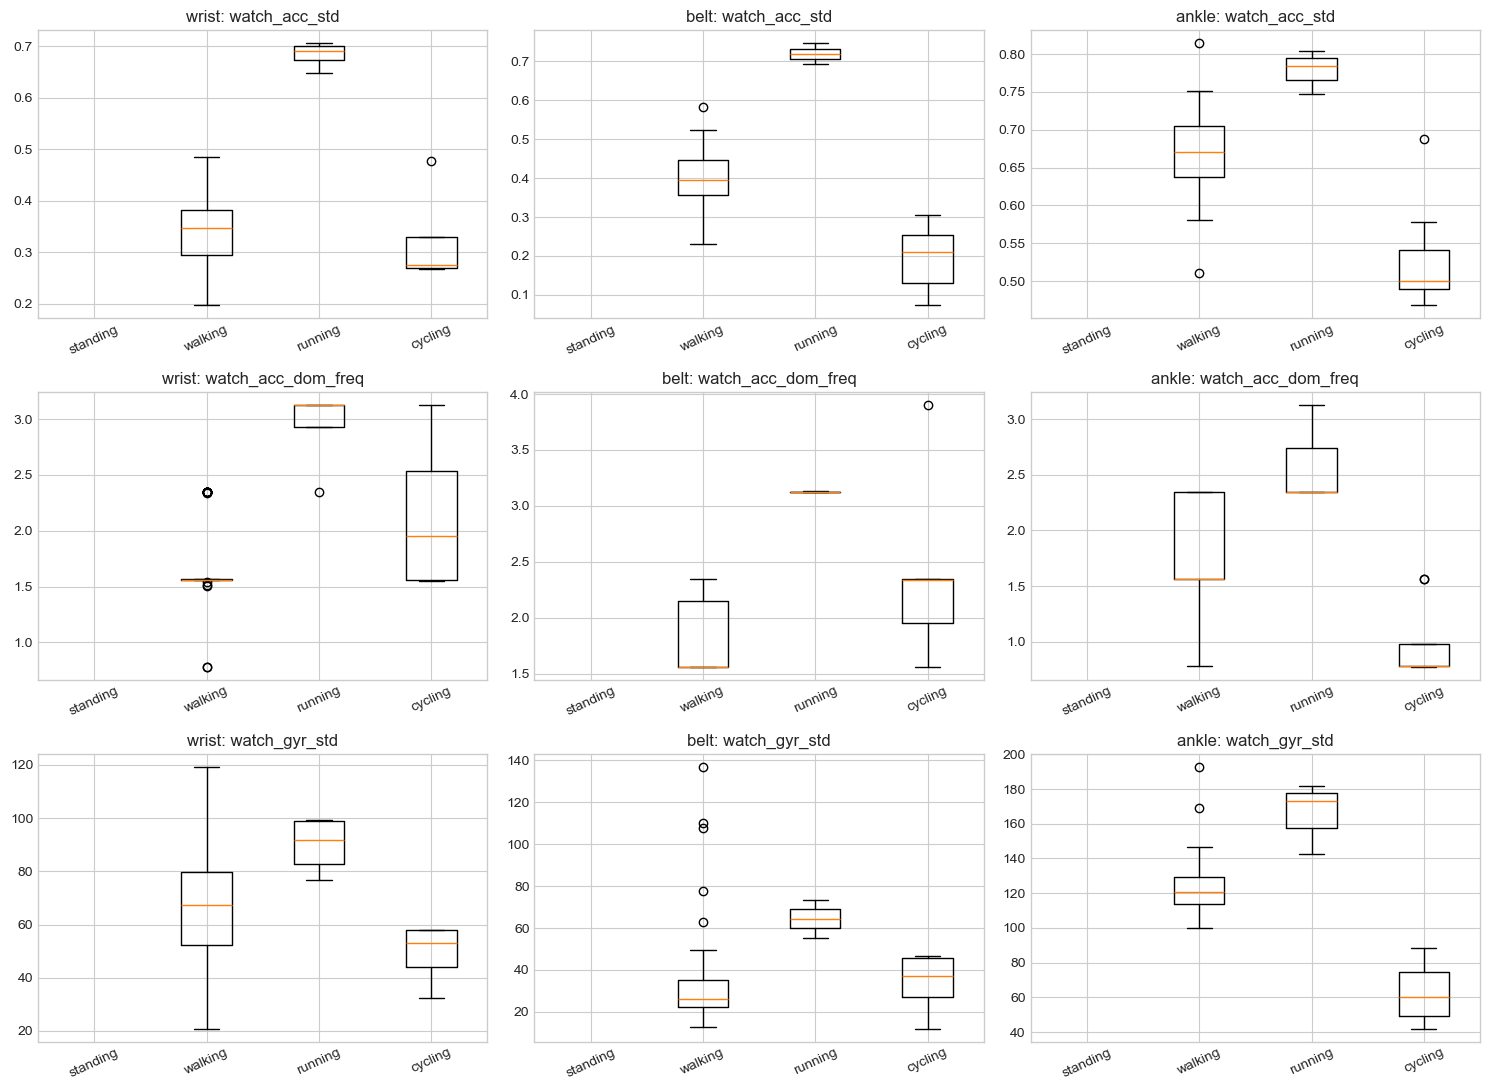

: 

In [ ]:
watch_locations = ["wrist", "belt", "ankle"]
plot_features = ["watch_acc_std", "watch_acc_dom_freq", "watch_gyr_std"]

fig, axes = plt.subplots(len(plot_features), len(watch_locations), figsize=(15, 11), sharex=False)

for row_idx, feature_name in enumerate(plot_features):
    for col_idx, watch_loc_name in enumerate(watch_locations):
        ax = axes[row_idx, col_idx]
        subset = activity_feature_df.loc[activity_feature_df["watch_loc_name"] == watch_loc_name]
        groups = [
            subset.loc[subset["activity_label"] == activity, feature_name].dropna().values
            for activity in ACTIVITY_ORDER
        ]
        ax.boxplot(groups, labels=ACTIVITY_ORDER)
        ax.set_title(f"{watch_loc_name}: {feature_name}")
        ax.tick_params(axis="x", rotation=25)

plt.tight_layout()
plt.show()

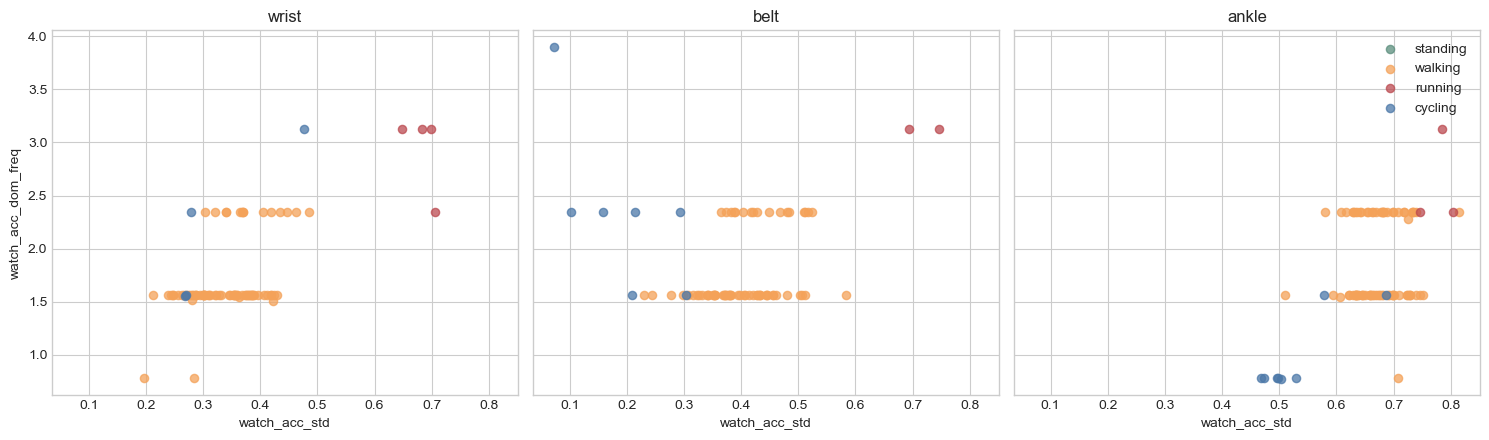

: 

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharex=True, sharey=True)

for ax, watch_loc_name in zip(axes, watch_locations):
    subset = activity_feature_df.loc[activity_feature_df["watch_loc_name"] == watch_loc_name]
    for activity in ACTIVITY_ORDER:
        activity_subset = subset.loc[subset["activity_label"] == activity]
        ax.scatter(
            activity_subset["watch_acc_std"],
            activity_subset["watch_acc_dom_freq"],
            label=activity,
            alpha=0.75,
            s=35,
            color=colors[activity],
        )
    ax.set_title(watch_loc_name)
    ax.set_xlabel("watch_acc_std")

axes[0].set_ylabel("watch_acc_dom_freq")
axes[-1].legend(loc="best")
plt.tight_layout()
plt.show()

## 9. Temporal Window Analysis For The 60-Second Rule

The assignment constraint changes the interpretation of the labels: an activity should only count if it persists for at least 60 seconds. That means we should not only study whole-recording averages. Instead, we split recordings into shorter windows, inspect how the motion features evolve over time, and later aggregate local evidence into sustained segments.

In [24]:
WINDOW_S = 15.0
HOP_S = 5.0
MIN_ACTIVITY_S = 60.0


def extract_window_feature_rows(recording, window_s=WINDOW_S, hop_s=HOP_S):
    rows = []

    base_keys = ["ax", "ay", "az"]
    if not all(key in recording.data for key in base_keys):
        return pd.DataFrame()

    base_trace = recording.data[base_keys[0]]
    fs = float(base_trace.samplerate)
    if fs <= 0:
        return pd.DataFrame()

    window_n = max(int(window_s * fs), 1)
    hop_n = max(int(hop_s * fs), 1)
    total_n = len(base_trace.values)

    if total_n < window_n:
        return pd.DataFrame()

    for start_idx in range(0, total_n - window_n + 1, hop_n):
        end_idx = start_idx + window_n
        row = {
            "start_s": start_idx / fs,
            "end_s": end_idx / fs,
            "mid_s": (start_idx + end_idx) / (2 * fs),
            "window_s": window_s,
            "hop_s": hop_s,
        }

        for prefix, keys in MOTION_GROUPS.items():
            if not all(key in recording.data for key in keys):
                continue

            stacked = np.vstack([
                recording.data[key].values[start_idx:end_idx].astype(float)
                for key in keys
            ])
            magnitude = np.sqrt((stacked ** 2).sum(axis=0))
            samplerate = float(np.mean([recording.data[key].samplerate for key in keys]))

            for feature_name, value in summarize_signal(magnitude, samplerate).items():
                row[f"{prefix}_{feature_name}"] = value

        rows.append(row)

    return pd.DataFrame(rows)


def longest_positive_run(mask, hop_s=HOP_S, window_s=WINDOW_S):
    best = 0.0
    current = 0
    for flag in mask:
        if bool(flag):
            current += 1
            duration = window_s + max(current - 1, 0) * hop_s
            best = max(best, duration)
        else:
            current = 0
    return best


In [25]:
multilabel_examples = metadata_df.loc[metadata_df["n_activities"] >= 2, ["file", "activity_combo", "watch_loc", "duration_s", "n_activities"]].copy()
multilabel_examples = multilabel_examples.sort_values(["n_activities", "duration_s"], ascending=[True, False])
multilabel_examples.head(12)

,file,activity_combo,watch_loc,duration_s,n_activities
1,train_trace_001.pkl,standing + walking,1,788.925,2
139,train_trace_139.pkl,standing + walking,2,778.934,2
340,train_trace_340.pkl,standing + walking,0,774.011,2
28,train_trace_028.pkl,standing + walking,0,755.095,2
141,train_trace_141.pkl,standing + walking,1,740.898,2
381,train_trace_381.pkl,standing + walking,0,718.600,2
279,train_trace_279.pkl,standing + walking,0,705.292,2
122,train_trace_122.pkl,standing + walking,0,700.600,2
201,train_trace_201.pkl,standing + walking,1,692.145,2
23,train_trace_023.pkl,standing + walking,0,690.628,2


In [26]:
example_multilabel_file = multilabel_examples.iloc[0]["file"]
example_multilabel_recording = Recording(str(TRAIN_DIR / example_multilabel_file))
example_window_df = extract_window_feature_rows(example_multilabel_recording)

print(example_multilabel_file)
print(example_multilabel_recording.labels)
example_window_df.head()

train_trace_001.pkl
{'path_idx': 1, 'activities': [0, 1], 'step_count': None, 'watch_loc': 1}


,start_s,end_s,mid_s,window_s,hop_s,watch_acc_mean,watch_acc_std,watch_acc_rms,watch_acc_iqr,watch_acc_dom_freq,watch_gyr_mean,watch_gyr_std,watch_gyr_rms,watch_gyr_iqr,watch_gyr_dom_freq,phone_acc_mean,phone_acc_std,phone_acc_rms,phone_acc_iqr,phone_acc_dom_freq,phone_gyr_mean,phone_gyr_std,phone_gyr_rms,phone_gyr_iqr,phone_gyr_dom_freq,phone_linacc_mean,phone_linacc_std,phone_linacc_rms,phone_linacc_iqr,phone_linacc_dom_freq
0,0.000000,14.996500,7.498250,15.0,5.0,1.119509,0.451951,1.207295,0.535619,2.341953,108.704750,69.643569,129.100539,102.568760,0.780651,10.252306,4.161539,11.064727,5.911491,1.95747,1.454305,0.967788,1.746888,1.229196,0.391494,4.400672,2.533138,5.077667,2.999503,6.263903
1,4.998833,19.995334,12.497084,15.0,5.0,1.141661,0.486056,1.240822,0.657428,2.341953,124.653062,62.892517,139.620395,83.646774,0.780651,10.530386,5.104166,11.702202,8.074886,1.95747,1.812596,1.010423,2.075201,1.424571,0.391494,5.614973,2.878915,6.309998,3.695141,6.263903
2,9.997667,24.994167,17.495917,15.0,5.0,1.150457,0.459284,1.238747,0.632607,2.341953,118.814195,61.115861,133.611232,80.163302,1.561302,10.636399,5.525329,11.985919,9.239465,1.95747,1.933100,1.088571,2.218528,1.443856,1.957470,6.114825,3.098026,6.854842,4.005826,6.263903
3,14.996500,29.993001,22.494750,15.0,5.0,1.173688,0.498383,1.275119,0.697444,2.341953,133.967385,73.650249,152.877793,92.322930,0.780651,10.564772,5.404249,11.866773,8.650283,1.95747,2.004310,1.245906,2.359987,1.466009,0.782988,5.960025,3.063166,6.701111,3.917980,3.914940
4,19.995334,34.991834,27.493584,15.0,5.0,1.187647,0.550284,1.308938,0.780564,2.341953,156.947767,83.289454,177.678740,109.377165,1.561302,10.598653,5.511929,11.946247,8.439281,1.95747,1.985561,1.306240,2.376703,1.508579,0.782988,5.950584,3.295710,6.802290,3.754494,3.914940


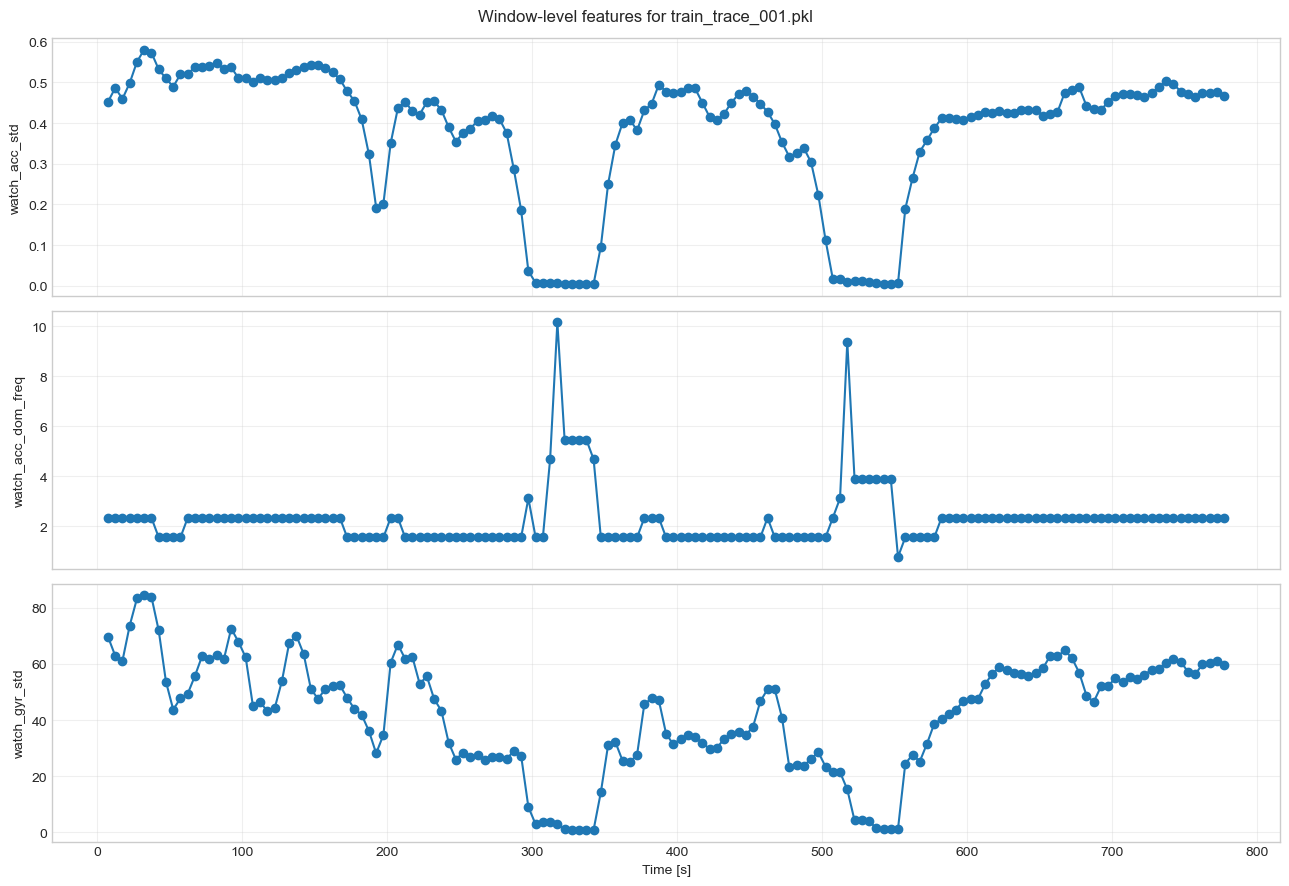

In [27]:
fig, axes = plt.subplots(3, 1, figsize=(13, 9), sharex=True)
window_plot_features = ["watch_acc_std", "watch_acc_dom_freq", "watch_gyr_std"]

for ax, feature_name in zip(axes, window_plot_features):
    ax.plot(example_window_df["mid_s"], example_window_df[feature_name], marker="o", linewidth=1.5)
    ax.set_ylabel(feature_name)
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel("Time [s]")
fig.suptitle(f"Window-level features for {example_multilabel_file}")
plt.tight_layout()
plt.show()

In [36]:
activity_recognizer = build_activity_recognizer(TRAIN_DIR)
activity_eval_df = evaluate_activity_recognizer(activity_recognizer, TRAIN_DIR)
activity_metric_series = activity_f1_summary(activity_eval_df)

print("Weak-label proxy F1 on the training recordings")
display(activity_metric_series.rename("f1").to_frame())


Weak-label proxy F1 on the training recordings


,f1
standing,0.967742
walking,0.991758
running,0.877698
cycling,0.953271
macro,0.947617


In [ ]:
# ============================================================
# Test-set prediction: activity classification only
# ============================================================

import re
from pathlib import Path

try:
    from tqdm.auto import tqdm
except Exception:
    tqdm = lambda iterable, **kwargs: iterable

# Use the same activity order as the project / activity_recognition.py
ACTIVITY_COLUMNS = ["standing", "walking", "running", "cycling"]

# Full Kaggle submission schema.
# We only predict the four activity columns here.
# The other columns are kept as dummy placeholders.
SUBMISSION_COLUMNS = [
    "Id",
    "watch_loc",
    "path_idx",
    "standing",
    "walking",
    "running",
    "cycling",
    "step_count",
]

OUTPUT_CSV = "submission.csv"


def extract_recording_id(path):
    """
    Extract the numeric test Id from filenames such as:
    test_000.pkl, recording_012.pkl, trace_279.pkl, or 279.pkl.
    """
    path = Path(path)
    match = re.search(r"(\d+)\.pkl$", path.name)
    if match is None:
        raise ValueError(f"Could not extract numeric Id from filename: {path.name}")
    return int(match.group(1))


def get_test_paths():
    """
    Works with either:
    - your activity_analysis.ipynb, where TEST_DIR is defined, or
    - the submission template, where filenames / dir_traces may be defined.
    """
    if "filenames" in globals() and len(filenames) > 0:
        paths = [Path(filename) for filename in filenames]
    elif "TEST_DIR" in globals():
        paths = sorted(Path(TEST_DIR).glob("*.pkl"))
    elif "dir_traces" in globals():
        paths = sorted(Path(dir_traces).glob("*.pkl"))
    else:
        raise RuntimeError(
            "No test directory found. Define TEST_DIR or dir_traces before running this cell."
        )

    paths = [path for path in paths if path.suffix == ".pkl"]

    if len(paths) == 0:
        raise FileNotFoundError(
            "No .pkl files found for the test set. Check TEST_DIR or dir_traces."
        )

    return sorted(paths, key=extract_recording_id)


# Make sure the trained recognizer exists.
if "activity_recognizer" not in globals():
    raise RuntimeError(
        "activity_recognizer was not found. Run the training cell first:\n"
        "activity_recognizer = build_activity_recognizer(TRAIN_DIR)"
    )

# Make sure Recording exists in this notebook.
try:
    Recording
except NameError:
    from mhealth_activity import Recording


test_paths = get_test_paths()
submission_rows = []
failed_files = []

for path in tqdm(test_paths, desc="Predicting activity labels"):
    recording_id = extract_recording_id(path)

    try:
        recording = Recording(str(path))
        activity_prediction = activity_recognizer.predict_activities(recording)

        standing = bool(activity_prediction.get("standing", False))
        walking = bool(activity_prediction.get("walking", False))
        running = bool(activity_prediction.get("running", False))
        cycling = bool(activity_prediction.get("cycling", False))

    except Exception as err:
        # Do not let one bad trace crash the full submission.
        # Failed traces get conservative all-False activity labels.
        failed_files.append((path.name, repr(err)))

        standing = False
        walking = False
        running = False
        cycling = False

    submission_rows.append(
        {
            "Id": int(recording_id),

            # Dummy placeholders for tasks we are not solving here.
            "watch_loc": 0,
            "path_idx": 0,
            "step_count": -1,

            # Actual activity predictions.
            "standing": standing,
            "walking": walking,
            "running": running,
            "cycling": cycling,
        }
    )


submission_df = (
    pd.DataFrame(submission_rows)
    .sort_values("Id")
    .reset_index(drop=True)
)

submission_df = submission_df[SUBMISSION_COLUMNS]

# Enforce expected dtypes.
submission_df["Id"] = submission_df["Id"].astype(int)
submission_df["watch_loc"] = submission_df["watch_loc"].astype(int)
submission_df["path_idx"] = submission_df["path_idx"].astype(int)
submission_df["step_count"] = submission_df["step_count"].astype(int)

for column in ACTIVITY_COLUMNS:
    submission_df[column] = submission_df[column].astype(bool)

# Basic checks before saving.
assert list(submission_df.columns) == SUBMISSION_COLUMNS
assert submission_df["Id"].is_unique
assert not submission_df.isna().any().any()

submission_df.to_csv(OUTPUT_CSV, index=False)

print(f"Saved activity-only predictions to: {OUTPUT_CSV}")
print(f"Number of test recordings: {len(submission_df)}")

print("\nPredicted positive counts:")
display(submission_df[ACTIVITY_COLUMNS].sum().rename("n_positive").to_frame())

if failed_files:
    print(f"\nWarning: {len(failed_files)} files failed and were assigned all-False activity labels.")
    print("First few failures:")
    for filename, error_message in failed_files[:10]:
        print(f"- {filename}: {error_message}")

display(submission_df.head())

Saved activity-only predictions to: submission.csv
Number of test recordings: 280

Predicted positive counts:


,n_positive
standing,57
walking,266
running,34
cycling,35


,Id,watch_loc,path_idx,standing,walking,running,cycling,step_count
0,0,0,0,True,True,True,False,-1
1,1,0,0,False,True,False,True,-1
2,2,0,0,True,True,False,True,-1
3,3,0,0,False,True,False,False,-1
4,4,0,0,False,True,False,False,-1


: 

In [29]:
example_window_labeled_df = activity_recognizer.label_windows(example_multilabel_recording)
example_sustained_summary = activity_recognizer.summarize_labeled_windows(example_window_labeled_df)

display(example_sustained_summary)
example_window_labeled_df[["start_s", "end_s", "watch_acc_std", "watch_acc_dom_freq", "watch_gyr_std", "raw_pred_label", "pred_label"]].head(12)

,activity,longest_run_s,meets_60s_rule
0,standing,70.0,True
1,walking,230.0,True
2,running,0.0,False
3,cycling,20.0,False


,start_s,end_s,watch_acc_std,watch_acc_dom_freq,watch_gyr_std,raw_pred_label,pred_label
0,0.000000,14.996500,0.451951,2.341953,69.643569,walking,walking
1,4.998833,19.995334,0.486056,2.341953,62.892517,walking,walking
2,9.997667,24.994167,0.459284,2.341953,61.115861,walking,walking
3,14.996500,29.993001,0.498383,2.341953,73.650249,walking,walking
4,19.995334,34.991834,0.550284,2.341953,83.289454,walking,walking
5,24.994167,39.990667,0.580475,2.341953,84.387238,walking,walking
6,29.993001,44.989501,0.572628,2.341953,83.817058,walking,walking
7,34.991834,49.988334,0.531699,1.561302,71.879337,walking,walking
8,39.990667,54.987168,0.509321,1.561302,53.648677,walking,walking
9,44.989501,59.986001,0.489284,1.561302,43.714367,walking,walking


## Notes For Next Steps

- The notebook now includes a full activity-recognition prototype instead of only an exploratory rule baseline.
- Window labels are learned from the clean single-activity recordings, while standing windows are approximated from the lowest-motion segments of traces that contain standing.
- The final output respects the assignment wording by aggregating window predictions into sustained runs and only returning `True` for activities that last at least 60 seconds.
- Short interruptions are bridged before aggregation so that brief pauses do not immediately break a walking or running segment.
- The metric shown in the notebook is still a proxy based on the weak training labels, so it is useful for iteration but not identical to the hidden Kaggle score.
- The implementation is centered on watch motion signals because they are always available and are less sensitive than phone signals to uncontrolled device placement.